In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [3]:
df = pd.read_csv("C://Users//Acer//OneDrive//Desktop//MNIST PROJECT//mnist_dataset.csv",nrows=1000)
x = df.drop(columns=['label'])
y = df['label']

Digit : 9


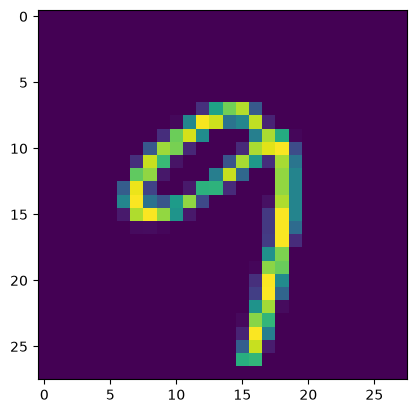

In [32]:
idx = np.random.randint(0,df.shape[0])
print(f"Digit : {y.iloc[idx]}")
plt.imshow(x.iloc[idx].values.reshape(28,28))

In [ ]:
# Train test split -->
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
# For visualization of decison region --->
pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

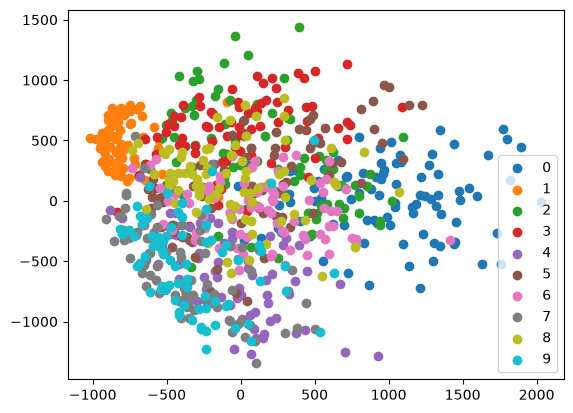

In [13]:
# Visualization in 2-D -->
for cls in np.unique(y_train):
    plt.scatter(
        x_train_pca[y_train == cls, 0],
        x_train_pca[y_train == cls, 1],
        label=cls
    )
plt.legend()
plt.show()


In [14]:
rf = RandomForestClassifier(n_estimators=100,max_samples=0.75,bootstrap=True,random_state=42,oob_score=True)
rf.fit(x_train,y_train)

# PCA one -->
rf_pca = RandomForestClassifier(n_estimators=100,max_samples=0.75,bootstrap=True,random_state=42,oob_score=True)
rf_pca.fit(x_train_pca,y_train)

,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples... versionadded:: 0.22.. versionchanged:: 1.9 Float `max_samples` is relative to `sample_weight.sum()` instead of `X.shape[0]` for weighted samples.",0.75
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node

In [19]:
print(f"OOB score(without PCA) = {rf.oob_score_} \nOOB score(with PCA) = {rf_pca.oob_score_}")

OOB score(without PCA) = 0.875 
OOB score(with PCA) = 0.405


In [23]:
cv = cross_val_score(rf,x_train,y_train,cv=7,scoring='accuracy')
cv_pca = cross_val_score(rf_pca,x_train_pca,y_train,cv=7,scoring='accuracy')
print(f"CV score (without pca) = {np.mean(cv)} \nCV score(pca) = {np.mean(cv_pca)}")
print()
print(f"Accuracy score (without pca) = {accuracy_score(y_test,rf.predict(x_test))} \nAccuracy score(pca) = {accuracy_score(y_test,rf_pca.predict(x_test_pca))}")

CV score (without pca) = 0.8749482401656314 
CV score(pca) = 0.39000762776506476

Accuracy score (without pca) = 0.84 
Accuracy score(pca) = 0.375


c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlxtend\plotting\decision_regions.py:346: UserWarning: You passed an edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


<Axes: >

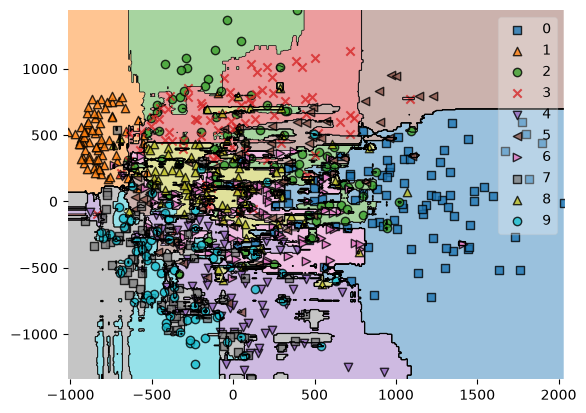

In [24]:
# decision region plot (pca) -->
plot_decision_regions(x_train_pca,np.array(y_train),rf_pca)

In [25]:
rf.feature_importances_

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

<Axes: >

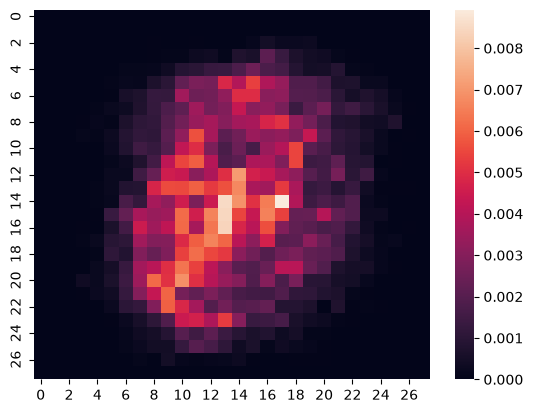

In [ ]:
# Shows area-wise importance in image -->
sns.heatmap(rf.feature_importances_.reshape(28,28))